Inspiration : https://github.com/BGasperov/drlformm.git


https://arxiv.org/pdf/2207.09951

In [ ]:
!pip install stable-baselines3[extra] gymnasium numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 5.9 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# crée le dossier si nécessaire
import os
os.makedirs("/content/drive/MyDrive/hawkes_mm", exist_ok=True)

SAVE_PATH = "/content/drive/MyDrive/hawkes_mm"
print(f"Sauvegarde dans : {SAVE_PATH}")

Mounted at /content/drive
Sauvegarde dans : /content/drive/MyDrive/hawkes_mm


#Reinforcement Learning

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces

In [ ]:
class MarketSimulatorWithHawkes:
    """
    Hawkes exponentiel bivarié — forme multiplicative.

    Intensité :
        lambda^b = A * exp(-k * delta_b) * (1 + y_b)
        lambda^a = A * exp(-k * delta_a) * (1 + y_a)

    Propriété : si delta → ∞, lambda → 0 (cohérent avec Guéant).

    Dynamique :
        y_b = y_b * exp(-beta*dt) + alpha_bb*dN_b + alpha_ba*dN_a
        y_a = y_a * exp(-beta*dt) + alpha_aa*dN_a + alpha_ab*dN_b

    Stabilité : rho(K) < 1 avec K_ij = alpha_ij / beta
    """

    def __init__(self, alpha_bb=0.3, alpha_aa=0.3,
                 alpha_ab=0.0, alpha_ba=0.0,
                 beta=1.5, A=1.0, k=1.5):

        self.alpha_bb = alpha_bb
        self.alpha_aa = alpha_aa
        self.alpha_ab = alpha_ab
        self.alpha_ba = alpha_ba
        self.beta     = beta
        self.A        = A
        self.k        = k

        K = np.array([
            [alpha_bb / beta, alpha_ba / beta],
            [alpha_ab / beta, alpha_aa / beta]
        ])
        rho = np.max(np.abs(np.linalg.eigvals(K)))
        assert rho < 1, f"Hawkes instable — rho(K)={rho:.3f} >= 1"

        self.reset()

    def reset(self):
        self.y_b = 0.0
        self.y_a = 0.0

    def intensity_bid(self, delta_b):
        return self.A * np.exp(-self.k * delta_b) * (1 + self.y_b)

    def intensity_ask(self, delta_a):
        return self.A * np.exp(-self.k * delta_a) * (1 + self.y_a)

    def step(self, delta_b, delta_a, dt):
        lam_b = self.intensity_bid(delta_b)
        lam_a = self.intensity_ask(delta_a)

        dN_b = int(np.random.rand() < lam_b * dt)
        dN_a = int(np.random.rand() < lam_a * dt)

        self.y_b = self.y_b * np.exp(-self.beta * dt) \
                 + self.alpha_bb * dN_b \
                 + self.alpha_ba * dN_a

        self.y_a = self.y_a * np.exp(-self.beta * dt) \
                 + self.alpha_aa * dN_a \
                 + self.alpha_ab * dN_b

        return dN_b, dN_a

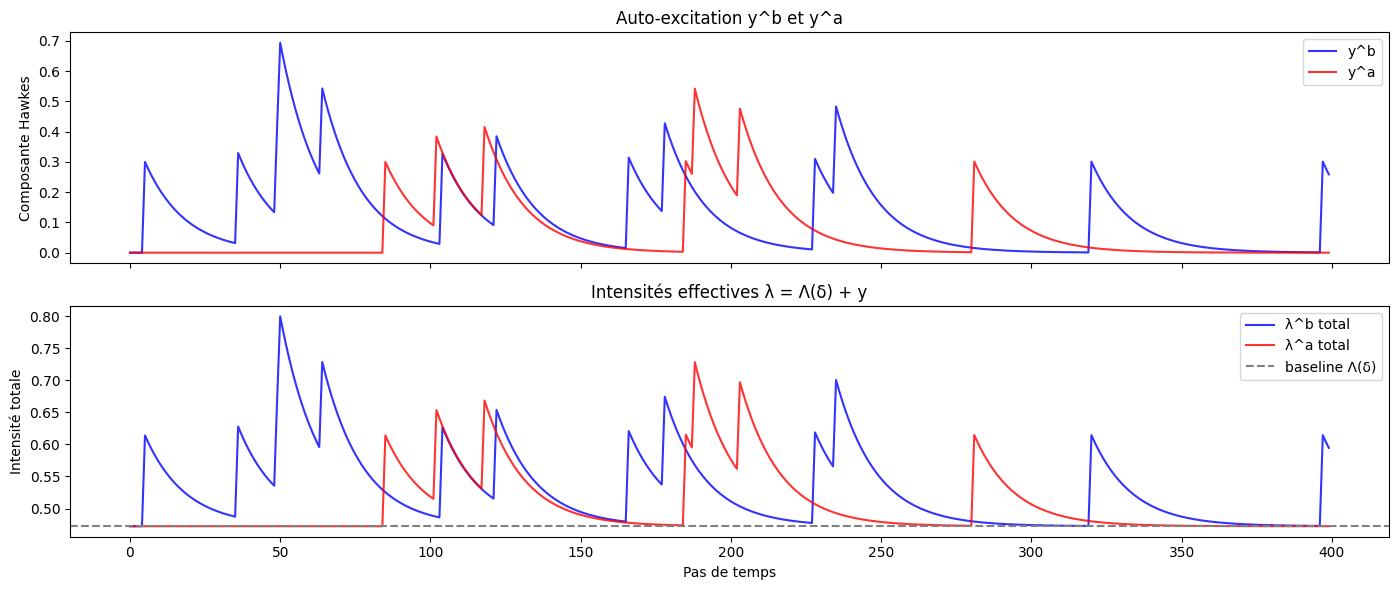

Intensité baseline : 0.472
y^b final : 0.259
y^a final : 0.000


In [ ]:
# Market Simulator test :

np.random.seed(42)
sim = MarketSimulatorWithHawkes(alpha_bb=0.3, alpha_aa=0.3, beta=1.5, A=1.0, k=1.5)

dt = 0.05
steps = 400
delta_b = delta_a = 0.5

y_b_hist, y_a_hist = [], []
lam_b_hist, lam_a_hist = [], []

for _ in range(steps):
    sim.step(delta_b, delta_a, dt)
    y_b_hist.append(sim.y_b)
    y_a_hist.append(sim.y_a)
    lam_b_hist.append(sim.intensity_bid(delta_b))
    lam_a_hist.append(sim.intensity_ask(delta_a))

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].plot(y_b_hist, label='y^b', color='blue', alpha=0.8)
axes[0].plot(y_a_hist, label='y^a', color='red', alpha=0.8)
axes[0].set_ylabel('Composante Hawkes')
axes[0].set_title('Auto-excitation y^b et y^a')
axes[0].legend()

axes[1].plot(lam_b_hist, label='λ^b total', color='blue', alpha=0.8)
axes[1].plot(lam_a_hist, label='λ^a total', color='red', alpha=0.8)
axes[1].axhline(sim.A * np.exp(-sim.k * delta_b),
                color='gray', linestyle='--', label='baseline Λ(δ)')
axes[1].set_ylabel('Intensité totale')
axes[1].set_xlabel('Pas de temps')
axes[1].set_title('Intensités effectives λ = Λ(δ) + y')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Intensité baseline : {sim.A * np.exp(-sim.k * delta_b):.3f}")
print(f"y^b final : {sim.y_b:.3f}")
print(f"y^a final : {sim.y_a:.3f}")

#Environnement RL

In [ ]:
class MarketMakingEnv(gym.Env):

    def __init__(self, T=100, dt=0.05, sigma=0.01, gamma=0.1,
                 Q=10, alpha_bb=0.3, alpha_aa=0.3,
                 alpha_ab=0.0, alpha_ba=0.0,
                 beta=1.5, A=1.0, k=1.5,
                 delta_min=0.01, delta_max=2.0, liq_penalty=1.0):

        super().__init__()
        self.T           = T
        self.dt          = dt
        self.sigma       = sigma
        self.gamma       = gamma
        self.Q           = Q
        self.delta_min   = delta_min
        self.delta_max   = delta_max
        self.liq_penalty = liq_penalty

        self.hawkes = MarketSimulatorWithHawkes(
            alpha_bb=alpha_bb, alpha_aa=alpha_aa,
            alpha_ab=alpha_ab, alpha_ba=alpha_ba,
            beta=beta, A=A, k=k
        )

        # y_max cohérent avec la forme multiplicative
        lambda_base = A * np.exp(-k * 1.0)
        denom = beta - alpha_bb * lambda_base
        y_mean = alpha_bb * lambda_base / denom if denom > 1e-8 else 1.0
        self.y_max = max(y_mean * 10, 0.5)

        self.action_space = spaces.Box(
            low=np.array([-1.0, -1.0], dtype=np.float32),
            high=np.array([1.0,  1.0], dtype=np.float32),
        )
        self.observation_space = spaces.Box(
            low=np.array( [0.0, -1.0, 0.0, 0.0], dtype=np.float32),
            high=np.array([1.0,  1.0, 5.0, 5.0], dtype=np.float32),
        )

    def _get_state(self):
        return np.array([
            self.t / self.T,
            self.q / self.Q,
            np.clip(self.hawkes.y_b / self.y_max, 0.0, 5.0),
            np.clip(self.hawkes.y_a / self.y_max, 0.0, 5.0),
        ], dtype=np.float32)

    def _denormalize_action(self, action):
        delta_b = self.delta_min + (action[0] + 1) / 2 \
                  * (self.delta_max - self.delta_min)
        delta_a = self.delta_min + (action[1] + 1) / 2 \
                  * (self.delta_max - self.delta_min)
        delta_b = np.clip(delta_b, self.delta_min, self.delta_max)
        delta_a = np.clip(delta_a, self.delta_min, self.delta_max)
        return delta_b, delta_a

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.t   = 0.0
        self.S   = 100.0
        self.q   = 0
        self.X   = 0.0
        self.pnl = 0.0
        self.hawkes.reset()
        return self._get_state(), {}

    def step(self, action):
        delta_b, delta_a = self._denormalize_action(action)

        if self.q >= self.Q:
            delta_b = self.delta_max
        if self.q <= -self.Q:
            delta_a = self.delta_max

        S_old = self.S

        dN_b, dN_a = self.hawkes.step(delta_b, delta_a, self.dt)

        fills_b = max(min(dN_b, self.Q - self.q), 0)
        fills_a = max(min(dN_a, self.Q + self.q), 0)

        self.q += fills_b - fills_a
        self.X -= fills_b * (S_old - delta_b)
        self.X += fills_a * (S_old + delta_a)

        self.S += self.sigma * np.sqrt(self.dt) * np.random.randn()

        pnl_new = self.X + self.q * self.S
        reward  = (pnl_new - self.pnl) \
                  - 0.5 * self.gamma * (self.sigma**2) * (self.q**2) * self.dt
        self.pnl = pnl_new
        self.t  += self.dt
        done     = self.t >= self.T

        if done:
            reward -= self.liq_penalty * (self.q ** 2)

        return self._get_state(), float(reward), done, False, {}

Steps          : 2001
PnL final      : 33.9025
Inventaire fin : 2
Reward moyen   : 0.014941
Reward total   : 29.8961


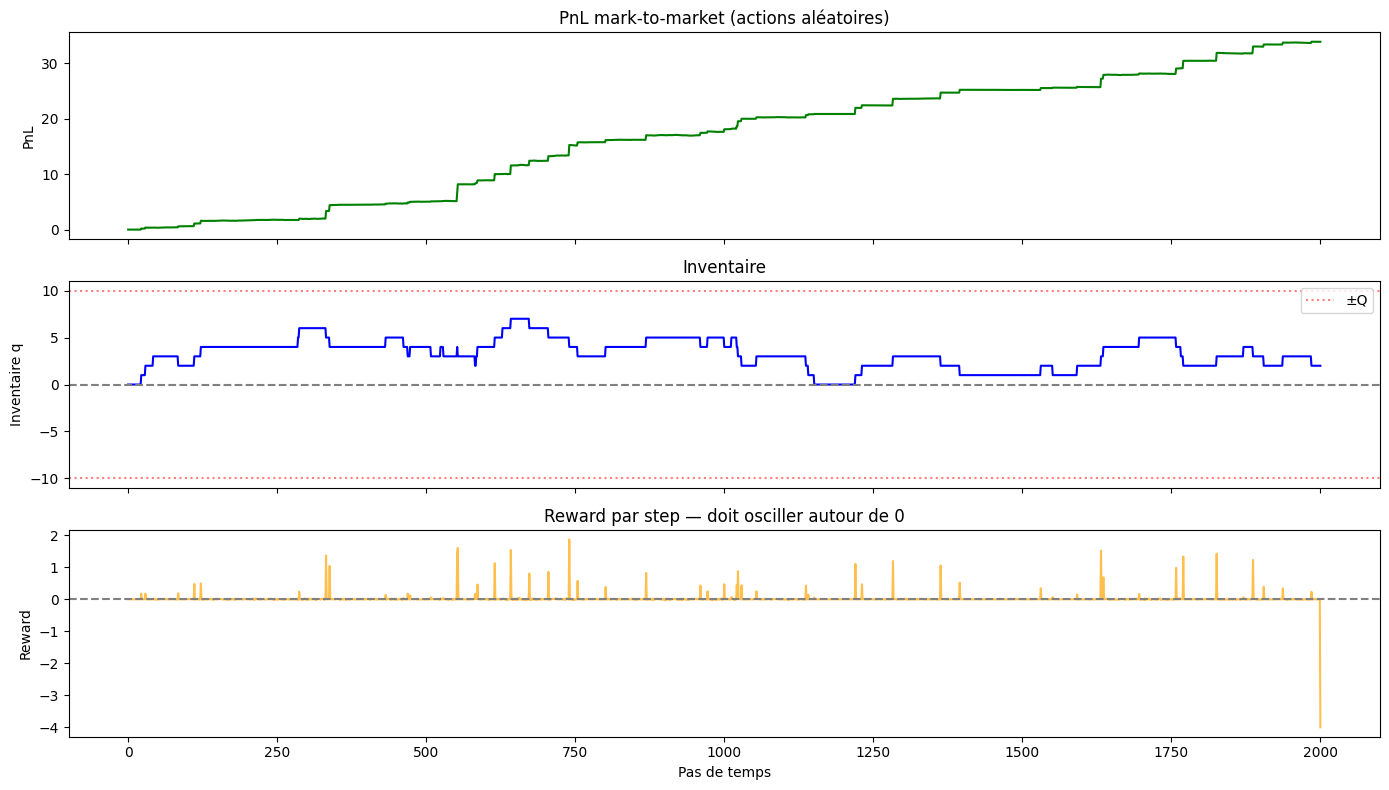

In [ ]:
#test env :
env = MarketMakingEnv(gamma=0.1, liq_penalty=1.0)
obs, _ = env.reset(seed=42)

rewards, inventories, pnls = [], [], []

while True:
    action = env.action_space.sample()
    obs, reward, done, _, _ = env.step(action)
    rewards.append(reward)
    inventories.append(env.q)
    pnls.append(env.pnl)
    if done:
        break

print(f"Steps          : {len(rewards)}")
print(f"PnL final      : {pnls[-1]:.4f}")
print(f"Inventaire fin : {env.q}")
print(f"Reward moyen   : {np.mean(rewards):.6f}")
print(f"Reward total   : {np.sum(rewards):.4f}")

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(pnls, color='green')
axes[0].set_ylabel('PnL')
axes[0].set_title('PnL mark-to-market (actions aléatoires)')

axes[1].plot(inventories, color='blue')
axes[1].axhline(0, color='gray', linestyle='--')
axes[1].axhline(env.Q,  color='red', linestyle=':', alpha=0.5, label='±Q')
axes[1].axhline(-env.Q, color='red', linestyle=':', alpha=0.5)
axes[1].set_ylabel('Inventaire q')
axes[1].set_title('Inventaire')
axes[1].legend()

axes[2].plot(rewards, color='orange', alpha=0.7)
axes[2].axhline(0, color='gray', linestyle='--')
axes[2].set_ylabel('Reward')
axes[2].set_title('Reward par step — doit osciller autour de 0')
axes[2].set_xlabel('Pas de temps')

plt.tight_layout()
plt.show()

#SAC

In [ ]:
from stable_baselines3 import SAC
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
import time

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
#adaptative learning rate against "catastrophic forgetting"
def linear_schedule(initial_lr, final_lr=1e-5):
    def schedule(progress):
        # progress : 1.0 → 0.0
        return final_lr + progress * (initial_lr - final_lr)
    return schedule

class TrainingCallback(BaseCallback):
    def __init__(self, check_freq=10_000):
        super().__init__()
        self.check_freq       = check_freq
        self.episode_rewards  = []
        self.current_rewards  = []
        self.best_mean_reward = -np.inf
        self.last_printed     = -1

    def _on_step(self):
        self.current_rewards.append(self.locals['rewards'][0])
        if self.locals['dones'][0]:
            self.episode_rewards.append(sum(self.current_rewards))
            self.current_rewards = []

        if (self.n_calls % self.check_freq == 0
                and self.n_calls != self.last_printed
                and len(self.episode_rewards) >= 10):

            self.last_printed = self.n_calls
            mean_r  = np.mean(self.episode_rewards[-10:])
            current_lr = self.model.learning_rate(
                1 - self.n_calls / self.locals['total_timesteps']
            )
            print(f"  Step {self.n_calls:>6} | "
                  f"Reward : {mean_r:>7.2f} | "
                  f"lr : {current_lr:.2e}", end="")

            if mean_r > self.best_mean_reward:
                self.best_mean_reward = mean_r
                self.model.save(f"{SAVE_PATH}/best_model")
                print("  ✓", end="")
            print()
        return True


env = MarketMakingEnv(
    T=100, dt=0.05, sigma=0.01,
    gamma=0.1, liq_penalty=1.0,
    A=1.0, k=1.5,
)

model = SAC(
    "MlpPolicy", env,
    verbose=0,
    gamma=1.0,
    batch_size=512,
    learning_rate=linear_schedule(3e-4, final_lr=1e-5),  # ← adaptatif
    policy_kwargs=dict(net_arch=[64, 64]),
    buffer_size=100_000,
    learning_starts=5_000,
    seed=42,
)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
callback = TrainingCallback(check_freq=10_000)

model.learn(
    total_timesteps=300_000,
    callback=callback,
    progress_bar=False,
)

model = SAC.load(f"{SAVE_PATH}/best_model", env=env)
print(f"\nMeilleur reward : {callback.best_mean_reward:.2f}")

  Step  30000 | Reward :  -33.13 | lr : 2.71e-04  ✓
  Step  40000 | Reward :  -40.44 | lr : 2.61e-04
  Step  50000 | Reward :  -14.29 | lr : 2.52e-04  ✓
  Step  60000 | Reward :  -18.28 | lr : 2.42e-04
  Step  70000 | Reward :  -44.89 | lr : 2.32e-04
  Step  80000 | Reward :  -52.85 | lr : 2.23e-04
  Step  90000 | Reward :  -60.66 | lr : 2.13e-04
  Step 100000 | Reward :  -27.24 | lr : 2.03e-04
  Step 110000 | Reward :   20.05 | lr : 1.94e-04  ✓
  Step 120000 | Reward :   23.21 | lr : 1.84e-04  ✓
  Step 130000 | Reward :    7.00 | lr : 1.74e-04
  Step 140000 | Reward :    7.93 | lr : 1.65e-04
  Step 150000 | Reward :    8.00 | lr : 1.55e-04
  Step 160000 | Reward :    3.13 | lr : 1.45e-04
  Step 170000 | Reward :   11.47 | lr : 1.36e-04
  Step 180000 | Reward :   -4.00 | lr : 1.26e-04
  Step 190000 | Reward :   -4.25 | lr : 1.16e-04
  Step 200000 | Reward :   16.12 | lr : 1.07e-04
  Step 210000 | Reward :   21.49 | lr : 9.70e-05
  Step 220000 | Reward :   19.97 | lr : 8.73e-05
  Step 2

In [ ]:
def backtest_comparison(model, env_params, n_episodes=300):

    def glft_spreads(q, sigma, gamma, k, A, y_b, y_a, Delta=1.0):
        """
        GLFT xi=0 (Model B) avec extension Hawkes A → A*(1+y).
        Pas de formule fermée exacte avec Hawkes — approximation.
        """
        A_eff_b = A * (1 + y_b)
        A_eff_a = A * (1 + y_a)
        term1   = Delta / k
        delta_b = term1 + (2*q + Delta)/2 \
                  * np.sqrt(gamma * sigma**2 / (2 * A_eff_b * k + 1e-8))
        delta_a = term1 - (2*q - Delta)/2 \
                  * np.sqrt(gamma * sigma**2 / (2 * A_eff_a * k + 1e-8))
        return max(float(delta_b), 0.001), max(float(delta_a), 0.001)

    def to_action(db, da, delta_min, delta_max):
        def norm(d):
            return float(np.clip(
                2*(d - delta_min)/(delta_max - delta_min) - 1, -1.0, 1.0
            ))
        return np.array([norm(db), norm(da)], dtype=np.float32)

    strategies = ['sac', 'guéant_hawkes', 'guéant_poisson', 'random']
    colors     = {
        'sac':            'blue',
        'guéant_hawkes':  'green',
        'guéant_poisson': 'orange',
        'random':         'gray',
    }
    results = {s: {'pnl': [], 'inventory': []} for s in strategies}

    for ep in range(n_episodes):
        for strategy in strategies:
            env    = MarketMakingEnv(**env_params)
            obs, _ = env.reset(seed=ep)

            while True:
                if strategy == 'sac':
                    action, _ = model.predict(obs, deterministic=True)

                elif strategy == 'guéant_hawkes':
                    db, da = glft_spreads(
                        q=env.q, sigma=env.sigma, gamma=env.gamma,
                        k=env.hawkes.k, A=env.hawkes.A,
                        y_b=env.hawkes.y_b, y_a=env.hawkes.y_a,
                    )
                    action = to_action(db, da, env.delta_min, env.delta_max)

                elif strategy == 'guéant_poisson':
                    db, da = glft_spreads(
                        q=env.q, sigma=env.sigma, gamma=env.gamma,
                        k=env.hawkes.k, A=env.hawkes.A,
                        y_b=0.0, y_a=0.0,
                    )
                    action = to_action(db, da, env.delta_min, env.delta_max)

                else:
                    action = env.action_space.sample()

                obs, _, done, _, _ = env.step(action)
                if done:
                    break

            results[strategy]['pnl'].append(env.pnl)
            results[strategy]['inventory'].append(abs(env.q))

    # --- métriques ---
    print("=" * 64)
    print(f"  {'Stratégie':<18} {'PnL moy':>9} {'Std':>9} "
          f"{'Sharpe':>9} {'|q| final':>9}")
    print("=" * 64)
    for s in strategies:
        m   = np.mean(results[s]['pnl'])
        std = np.std(results[s]['pnl'])
        print(f"  {s:<18} {m:>9.3f} {std:>9.3f} "
              f"{m/(std+1e-8):>9.3f} "
              f"{np.mean(results[s]['inventory']):>9.3f}")
    print("=" * 64)

    # --- graphes ---
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    for s in strategies:
        axes[0,0].hist(results[s]['pnl'], bins=40,
                       alpha=0.5, label=s, color=colors[s])
    axes[0,0].set_title('Distribution PnL final')
    axes[0,0].set_xlabel('PnL')
    axes[0,0].legend()

    means = [np.mean(results[s]['pnl']) for s in strategies]
    stds  = [np.std(results[s]['pnl'])  for s in strategies]
    axes[0,1].bar(strategies, means, yerr=stds, capsize=5,
                  color=[colors[s] for s in strategies], alpha=0.7)
    axes[0,1].set_title('PnL moyen ± std')
    axes[0,1].set_ylabel('PnL')
    axes[0,1].tick_params(axis='x', rotation=15)

    for s in strategies:
        axes[1,0].hist(results[s]['inventory'], bins=range(0, 12),
                       alpha=0.5, label=s, color=colors[s])
    axes[1,0].set_title('Distribution |inventaire final|')
    axes[1,0].set_xlabel('|q_T|')
    axes[1,0].legend()

    sharpes = [np.mean(results[s]['pnl']) /
               (np.std(results[s]['pnl']) + 1e-8)
               for s in strategies]
    axes[1,1].bar(strategies, sharpes,
                  color=[colors[s] for s in strategies], alpha=0.7)
    axes[1,1].set_title('Sharpe ratio')
    axes[1,1].set_ylabel('Sharpe')
    axes[1,1].tick_params(axis='x', rotation=15)

    plt.tight_layout()
    plt.show()

    return results

  Stratégie            PnL moy       Std    Sharpe |q| final
  sac                   44.728     6.320     7.077     2.453
  guéant_hawkes         51.610     6.771     7.622     5.173
  guéant_poisson        51.668     5.977     8.644     4.933
  random                37.759     6.850     5.512     4.920


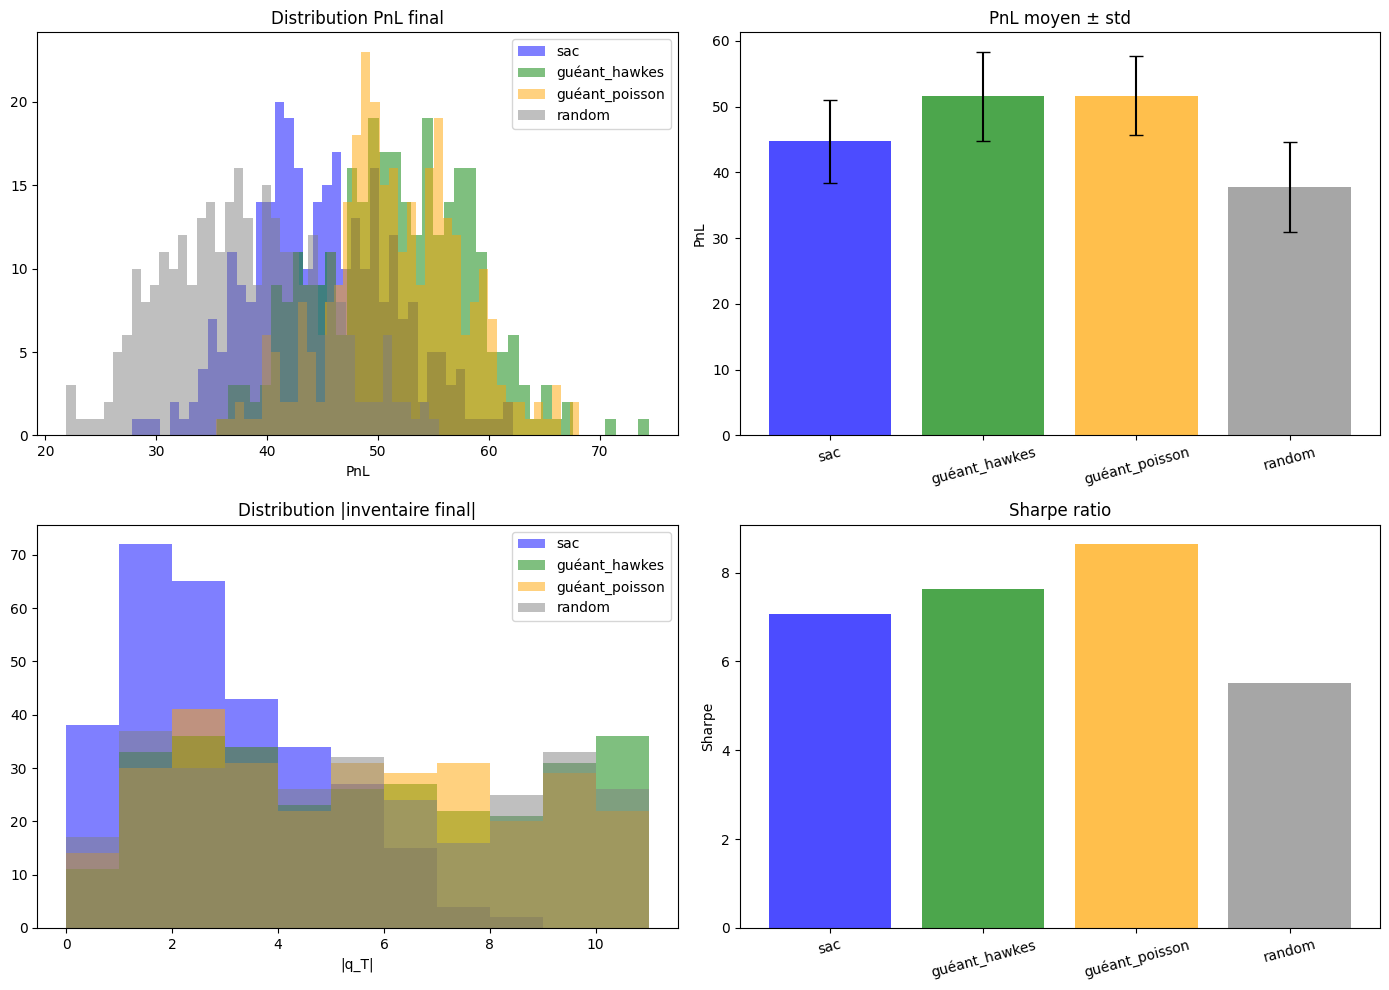

In [ ]:
env_params = dict(
    T=100,
    dt=0.05,
    sigma=0.01,
    gamma=0.1,
    liq_penalty=1.0,
    A=1.0,    # ← identique à l'entraînement
    k=1.5,
)

env = MarketMakingEnv(**env_params)
model = SAC.load(f"{SAVE_PATH}/best_model", env=env)

results = backtest_comparison(model, env_params, n_episodes=300)
